In [60]:
import os
import sys


CURRENT_DIR = os.getcwd()
FOLDERS = CURRENT_DIR.split(os.sep)
TESIS_FOLDER_INDEX = FOLDERS.index('S-noise-gradient')
CURRENT_DIR = os.sep.join(FOLDERS[:TESIS_FOLDER_INDEX+1])
LIBS_PATH = os.path.join(CURRENT_DIR, 'src', 'libs')
assert os.path.exists(LIBS_PATH)
sys.path.append(CURRENT_DIR)
sys.path.append(LIBS_PATH)


# Import external and local libraries
# __________________________________________________________________________________________________
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import torch.optim as optim
import json
from typing import List

# Locals
from utils import *
from dataset import DFDataset, TensorDataset
from models import *
import config as cfg
from dlnr import DLNoiseReduction


# Global / Path variables
# __________________________________________________________________________________________________
DATA_PATH = os.path.join(CURRENT_DIR, 'data', 'try_ts')
CHECKPOINT_PATH = os.path.join(CURRENT_DIR, 'checkpoints')
CONFIG_PATH = os.path.join(CURRENT_DIR, 'config')


# Make sure that the GPU is being used
# __________________________________________________________________________________________________
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
assert device.type == "cuda"

In [61]:
df = pd.read_parquet(os.path.join(DATA_PATH, 'pump_sensor_data', 'sensor.parquet'))
df

,Unnamed: 0,timestamp,sensor_00,sensor_01,sensor_02,sensor_03,sensor_04,sensor_05,sensor_06,sensor_07,...,sensor_43,sensor_44,sensor_45,sensor_46,sensor_47,sensor_48,sensor_49,sensor_50,sensor_51,machine_status
0,0,2018-04-01 00:00:00,2.465394,47.09201,53.211800,46.310760,634.375000,76.45975,13.41146,16.13136,...,41.92708,39.641200,65.68287,50.92593,38.194440,157.9861,67.70834,243.0556,201.3889,NORMAL
1,1,2018-04-01 00:01:00,2.465394,47.09201,53.211800,46.310760,634.375000,76.45975,13.41146,16.13136,...,41.92708,39.641200,65.68287,50.92593,38.194440,157.9861,67.70834,243.0556,201.3889,NORMAL
2,2,2018-04-01 00:02:00,2.444734,47.35243,53.211800,46.397570,638.888900,73.54598,13.32465,16.03733,...,41.66666,39.351852,65.39352,51.21528,38.194443,155.9606,67.12963,241.3194,203.7037,NORMAL
3,3,2018-04-01 00:03:00,2.460474,47.09201,53.168400,46.397568,628.125000,76.98898,13.31742,16.24711,...,40.88541,39.062500,64.81481,51.21528,38.194440,155.9606,66.84028,240.4514,203.1250,NORMAL
4,4,2018-04-01 00:04:00,2.445718,47.13541,53.211800,46.397568,636.458300,76.58897,13.35359,16.21094,...,41.40625,38.773150,65.10416,51.79398,38.773150,158.2755,66.55093,242.1875,201.3889,NORMAL
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
220315,220315,2018-08-31 23:55:00,2.407350,47.69965,50.520830,43.142361,634.722229,64.59095,15.11863,16.65220,...,38.28125,68.287030,52.37268,48.32176,41.087960,212.3843,153.64580,NaN,231.1921,NORMAL
220316,220316,2018-08-31 23:56:00,2.400463,47.69965,50.564240,43.142361,630.902771,65.83363,15.15480,16.70284,...,38.28125,66.840280,50.63657,48.03241,40.798610,213.8310,156.25000,NaN,231.1921,NORMAL
220317,220317,2018-08-31 23:57:00,2.396528,47.69965,50.520830,43.142361,625.925903,67.29445,15.08970,16.70284,...,39.06250,65.393520,48.90046,48.03241,40.798610,217.3032,155.38190,NaN,232.0602,NORMAL
220318,220318,2018-08-31 23:58:00,2.406366,47.69965,50.520832,43.142361,635.648100,65.09175,15.11863,16.56539,...,40.62500,64.236110,47.74306,48.32176,40.509258,222.5116,153.93520,NaN,234.0856,NORMAL


In [62]:
df.set_index('timestamp', inplace=True)
df.index = pd.to_datetime(df.index)
df.drop(columns=['Unnamed: 0'], inplace=True)
df

,sensor_00,sensor_01,sensor_02,sensor_03,sensor_04,sensor_05,sensor_06,sensor_07,sensor_08,sensor_09,...,sensor_43,sensor_44,sensor_45,sensor_46,sensor_47,sensor_48,sensor_49,sensor_50,sensor_51,machine_status
timestamp,,,,,,,,,,,,,,,,,,,,,
2018-04-01 00:00:00,2.465394,47.09201,53.211800,46.310760,634.375000,76.45975,13.41146,16.13136,15.56713,15.05353,...,41.92708,39.641200,65.68287,50.92593,38.194440,157.9861,67.70834,243.0556,201.3889,NORMAL
2018-04-01 00:01:00,2.465394,47.09201,53.211800,46.310760,634.375000,76.45975,13.41146,16.13136,15.56713,15.05353,...,41.92708,39.641200,65.68287,50.92593,38.194440,157.9861,67.70834,243.0556,201.3889,NORMAL
2018-04-01 00:02:00,2.444734,47.35243,53.211800,46.397570,638.888900,73.54598,13.32465,16.03733,15.61777,15.01013,...,41.66666,39.351852,65.39352,51.21528,38.194443,155.9606,67.12963,241.3194,203.7037,NORMAL
2018-04-01 00:03:00,2.460474,47.09201,53.168400,46.397568,628.125000,76.98898,13.31742,16.24711,15.69734,15.08247,...,40.88541,39.062500,64.81481,51.21528,38.194440,155.9606,66.84028,240.4514,203.1250,NORMAL
2018-04-01 00:04:00,2.445718,47.13541,53.211800,46.397568,636.458300,76.58897,13.35359,16.21094,15.69734,15.08247,...,41.40625,38.773150,65.10416,51.79398,38.773150,158.2755,66.55093,242.1875,201.3889,NORMAL
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2018-08-31 23:55:00,2.407350,47.69965,50.520830,43.142361,634.722229,64.59095,15.11863,16.65220,15.65393,15.16204,...,38.28125,68.287030,52.37268,48.32176,41.087960,212.3843,153.64580,NaN,231.1921,NORMAL
2018-08-31 23:56:00,2.400463,47.69965,50.564240,43.142361,630.902771,65.83363,15.15480,16.70284,15.65393,15.11863,...,38.28125,66.840280,50.63657,48.03241,40.798610,213.8310,156.25000,NaN,231.1921,NORMAL
2018-08-31 23:57:00,2.396528,47.69965,50.520830,43.142361,625.925903,67.29445,15.08970,16.70284,15.69734,15.11863,...,39.06250,65.393520,48.90046,48.03241,40.798610,217.3032,155.38190,NaN,232.0602,NORMAL


In [63]:
nan_counts = df.isna().sum()
print((nan_counts/len(df))*100)
print(nan_counts[(nan_counts/len(df))*100 > 20]/len(df)*100)

sensor_00           4.633261
sensor_01           0.167484
sensor_02           0.008624
sensor_03           0.008624
sensor_04           0.008624
sensor_05           0.008624
sensor_06           2.177741
sensor_07           2.474129
sensor_08           2.317992
sensor_09           2.085603
sensor_10           0.008624
sensor_11           0.008624
sensor_12           0.008624
sensor_13           0.008624
sensor_14           0.009532
sensor_15         100.000000
sensor_16           0.014070
sensor_17           0.020879
sensor_18           0.020879
sensor_19           0.007262
sensor_20           0.007262
sensor_21           0.007262
sensor_22           0.018609
sensor_23           0.007262
sensor_24           0.007262
sensor_25           0.016340
sensor_26           0.009078
sensor_27           0.007262
sensor_28           0.007262
sensor_29           0.032680
sensor_30           0.118464
sensor_31           0.007262
sensor_32           0.030864
sensor_33           0.007262
sensor_34     

In [64]:
df.drop(columns=['sensor_15', 'sensor_50'], inplace=True)

In [65]:
df['machine_status'] = df['machine_status'].replace({'NORMAL': 0, 'RECOVERING': 0.5, 'BROKEN': 1})
df

/tmp/ipykernel_11436/1818911474.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['machine_status'] = df['machine_status'].replace({'NORMAL': 0, 'RECOVERING': 0.5, 'BROKEN': 1})


,sensor_00,sensor_01,sensor_02,sensor_03,sensor_04,sensor_05,sensor_06,sensor_07,sensor_08,sensor_09,...,sensor_42,sensor_43,sensor_44,sensor_45,sensor_46,sensor_47,sensor_48,sensor_49,sensor_51,machine_status
timestamp,,,,,,,,,,,,,,,,,,,,,
2018-04-01 00:00:00,2.465394,47.09201,53.211800,46.310760,634.375000,76.45975,13.41146,16.13136,15.56713,15.05353,...,31.770832,41.92708,39.641200,65.68287,50.92593,38.194440,157.9861,67.70834,201.3889,0.0
2018-04-01 00:01:00,2.465394,47.09201,53.211800,46.310760,634.375000,76.45975,13.41146,16.13136,15.56713,15.05353,...,31.770832,41.92708,39.641200,65.68287,50.92593,38.194440,157.9861,67.70834,201.3889,0.0
2018-04-01 00:02:00,2.444734,47.35243,53.211800,46.397570,638.888900,73.54598,13.32465,16.03733,15.61777,15.01013,...,31.770830,41.66666,39.351852,65.39352,51.21528,38.194443,155.9606,67.12963,203.7037,0.0
2018-04-01 00:03:00,2.460474,47.09201,53.168400,46.397568,628.125000,76.98898,13.31742,16.24711,15.69734,15.08247,...,31.510420,40.88541,39.062500,64.81481,51.21528,38.194440,155.9606,66.84028,203.1250,0.0
2018-04-01 00:04:00,2.445718,47.13541,53.211800,46.397568,636.458300,76.58897,13.35359,16.21094,15.69734,15.08247,...,31.510420,41.40625,38.773150,65.10416,51.79398,38.773150,158.2755,66.55093,201.3889,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2018-08-31 23:55:00,2.407350,47.69965,50.520830,43.142361,634.722229,64.59095,15.11863,16.65220,15.65393,15.16204,...,30.208330,38.28125,68.287030,52.37268,48.32176,41.087960,212.3843,153.64580,231.1921,0.0
2018-08-31 23:56:00,2.400463,47.69965,50.564240,43.142361,630.902771,65.83363,15.15480,16.70284,15.65393,15.11863,...,29.947920,38.28125,66.840280,50.63657,48.03241,40.798610,213.8310,156.25000,231.1921,0.0
2018-08-31 23:57:00,2.396528,47.69965,50.520830,43.142361,625.925903,67.29445,15.08970,16.70284,15.69734,15.11863,...,30.208330,39.06250,65.393520,48.90046,48.03241,40.798610,217.3032,155.38190,232.0602,0.0


In [66]:
# Interpolar los datos faltantes
df.interpolate(method='time', inplace=True)

# Verificar si quedan valores faltantes
print(df.isna().sum().sum())

0


In [67]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
sensor_00,220320.0,2.274651,0.602488,0.000000,2.419155,2.455556,2.499826,2.549016
sensor_01,220320.0,47.597225,3.301698,0.000000,46.310760,48.133680,49.479160,56.727430
sensor_02,220320.0,50.867092,3.667314,33.159720,50.390620,51.649300,52.777770,56.032990
sensor_03,220320.0,43.752337,2.418979,31.640620,42.838539,44.227428,45.312500,48.220490
sensor_04,220320.0,590.664008,144.042132,2.798032,626.620400,632.638916,637.615723,800.000000
sensor_05,220320.0,73.394941,17.301057,0.000000,69.976258,75.576820,80.911770,99.999880
sensor_06,220320.0,13.209330,2.903099,0.014468,13.317420,13.628470,14.539930,22.251160
sensor_07,220320.0,15.475759,3.200112,0.000000,15.856480,16.167530,16.427950,23.596640
sensor_08,220320.0,14.861384,2.995187,0.028935,15.147570,15.451390,15.697340,24.348960
sensor_09,220320.0,14.491815,2.956146,0.000000,15.010130,15.082470,15.118630,25.000000


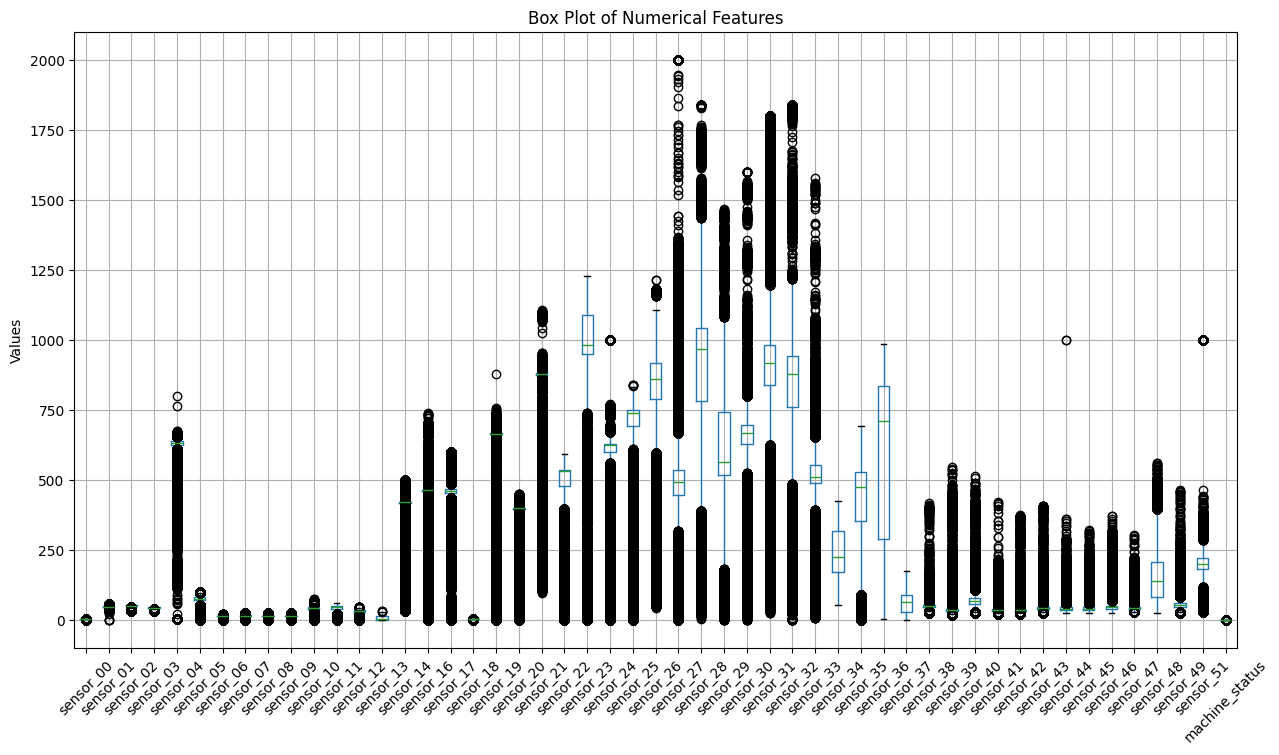

In [68]:
# Create a box plot for all numerical columns in the DataFrame
df.boxplot(figsize=(15, 8), rot=45)
plt.title("Box Plot of Numerical Features")
plt.ylabel("Values")
plt.show()

In [69]:
# Calcular el número de outliers para cada columna numérica
outliers_percentage = {}
for column in df.select_dtypes(include=[np.number]).columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers_percentage[column] = f'{round(((df[column] < lower_bound) | (df[column] > upper_bound)).sum()/len(df) * 100, 4)} %'

# Mostrar el número de outliers por columna
outliers_percentage

{'sensor_00': '11.0444 %',
 'sensor_01': '6.1638 %',
 'sensor_02': '7.0311 %',
 'sensor_03': '4.8684 %',
 'sensor_04': '12.3647 %',
 'sensor_05': '8.7899 %',
 'sensor_06': '7.4909 %',
 'sensor_07': '8.051 %',
 'sensor_08': '9.3205 %',
 'sensor_09': '26.8292 %',
 'sensor_10': '8.5421 %',
 'sensor_11': '8.1146 %',
 'sensor_12': '13.0179 %',
 'sensor_13': '0.0014 %',
 'sensor_14': '26.3984 %',
 'sensor_16': '22.1578 %',
 'sensor_17': '17.2327 %',
 'sensor_18': '17.2068 %',
 'sensor_19': '26.3753 %',
 'sensor_20': '27.0434 %',
 'sensor_21': '25.4471 %',
 'sensor_22': '12.692 %',
 'sensor_23': '11.8918 %',
 'sensor_24': '14.0773 %',
 'sensor_25': '12.9366 %',
 'sensor_26': '12.6802 %',
 'sensor_27': '14.8675 %',
 'sensor_28': '12.5517 %',
 'sensor_29': '12.0125 %',
 'sensor_30': '16.9767 %',
 'sensor_31': '14.8035 %',
 'sensor_32': '12.1668 %',
 'sensor_33': '13.6197 %',
 'sensor_34': '0.0 %',
 'sensor_35': '4.6215 %',
 'sensor_36': '0.0 %',
 'sensor_37': '0.0 %',
 'sensor_38': '7.3597 %',


In [70]:
df['y'] = df['machine_status']
df.drop(columns=['machine_status'], inplace=True)

In [71]:
df.to_parquet(os.path.join(DATA_PATH, 'pump_sensor_data', 'clean.parquet'))